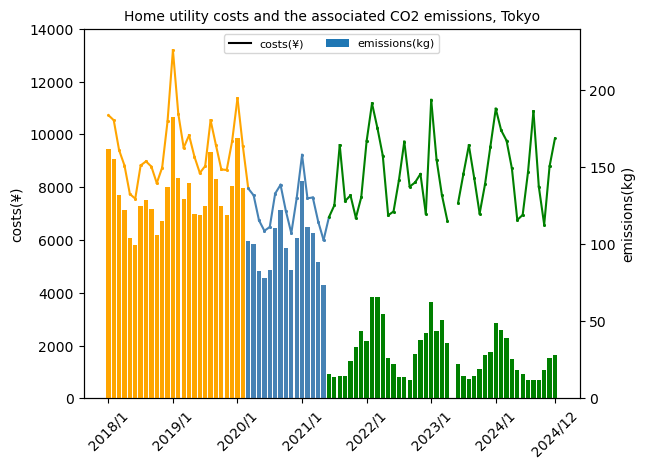

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

clr = ['orange', 'steelblue', 'green']

df = pd.read_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/電力源/二酸化炭素排出量.csv')
#print(df)

dfx = df.copy()
dfx[['total_cost', 'electricity', 'gas', 'water']] = dfx[['total_cost', 'electricity', 'gas', 'water']].replace(',', '', regex=True).astype('float')
#print(dfx)

#print(dfx.dtypes)

fig, ax1 = plt.subplots()
plt.title('Home utility costs and the associated CO2 emissions, Tokyo', fontsize=10)
ax2 = ax1.twinx()

# 2軸グラフの本体設定
for i in range(len(dfx)):
    ax2.bar(dfx['Y/M'].iloc[i], dfx['emissions'].iloc[i], color=clr[dfx['status'].iloc[i]])
L = 100
for i in range(L):
    ax1.plot((dfx['Y/M'].iloc[2*i], dfx['Y/M'].iloc[2*i+1]), (dfx['total_cost'].iloc[2*i], dfx['total_cost'].iloc[2*i+1]), marker='o', markersize=1,color=clr[dfx['status'].iloc[2*i]])
    if (2*i+2) > (len(dfx)-1):
        break
    ax1.plot((dfx['Y/M'].iloc[2*i+1], dfx['Y/M'].iloc[2*i+2]), (dfx['total_cost'].iloc[2*i+1], dfx['total_cost'].iloc[2*i+2]), marker='o',markersize=1,color=clr[dfx['status'].iloc[2*i+1]])

plt.bar([],[], color='k', label='emissions(kg)')
plt.plot([],[], color='k', label='costs(¥)')

ax1.tick_params(axis='x', colors='k', labelrotation=45)
idx = dfx['Y/M'][::12].to_numpy()
#print(dfx['Y/M'].iloc[len(dfx)-1])
index = np.append(idx, dfx['Y/M'].iloc[len(dfx)-1])
#print(idx)
ax1.set_xticks(index)

#index = [idx for i in range(len(dfx)-2) for idx in dfx['Y/M'].iloc[i+2]]
#print(index)

#ax1.set_xlim([dfx['Y/M'].iloc[0], dfx['Y/M'].iloc[len(dfx)-1]])
ax1.set_ylim([0, 14000])
ax2.set_ylim([0, 240])

ax2.set_xlabel('year/month', fontsize=10)
ax1.set_ylabel('costs(¥)', fontsize=10)
ax2.set_ylabel('emissions(kg)', fontsize=10)

plt.legend(ncol=2, loc='upper center', fontsize=8)
plt.show()

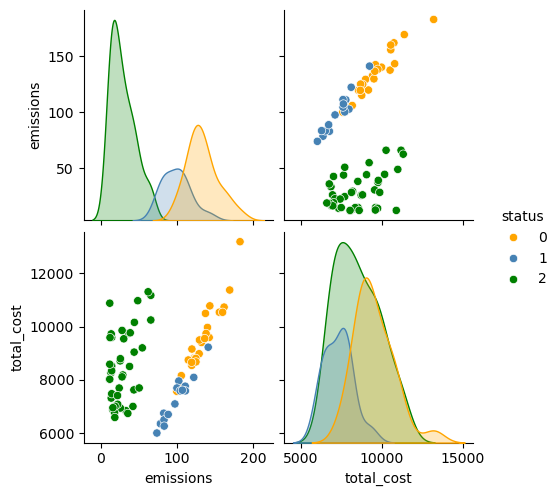

In [4]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dfx2 = dfx[['emissions', 'total_cost', 'status']]

sns.pairplot(dfx2, hue='status', palette=['orange', 'steelblue', 'green'])



         emissions
status            
0       133.139615
1        99.132667
2        28.992619
Reduction rate = 0.7822389755005315


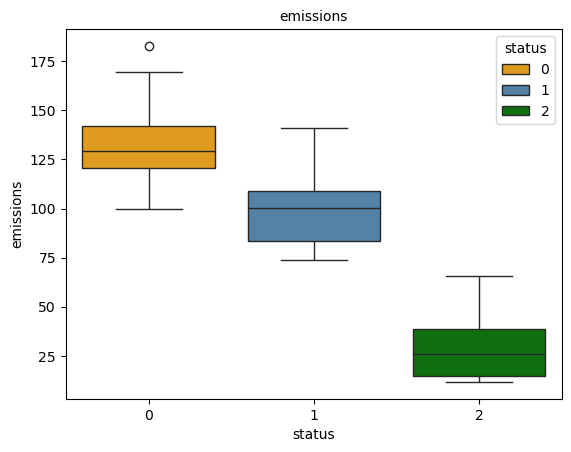

"\nsns.boxplot(data2, x='status', y='cost', hue='status' )\nplt.show()\n\nsns.boxplot(data3, x='status', y='electricity', hue='status' )\nplt.show()\n\nsns.boxplot(data4, x='status', y='gas', hue='status' )\nplt.show()\n\nsns.boxplot(data5, x='status', y='water', hue='status' )\nplt.show()\n"

In [26]:

#☟箱ひげ図1つの時との違いは,ここでデータを2個引用するだけ！☟

data1 = dfx[['emissions', 'status']]

d_mean = data1.groupby('status').mean()

print(d_mean)

print(f'Reduction rate = {1-d_mean['emissions'].iloc[2]/d_mean['emissions'].iloc[0]}')

data2 = dfx[['total_cost', 'status']]
data3 = dfx[['electricity', 'gas', 'water', 'status']]

data4 = dfx[['gas', 'status']]

data5 = dfx[['water', 'status']]

plt.title('emissions', fontsize=10)
#ax.boxplot((data0['emissions'],data1['emissions'], data2['emissions']))
sns.boxplot(data1, x='status', y='emissions', hue='status', palette=['orange', 'steelblue', 'green'])
plt.show()

"""
sns.boxplot(data2, x='status', y='cost', hue='status' )
plt.show()

sns.boxplot(data3, x='status', y='electricity', hue='status' )
plt.show()

sns.boxplot(data4, x='status', y='gas', hue='status' )
plt.show()

sns.boxplot(data5, x='status', y='water', hue='status' )
plt.show()
"""


15
         total_cost  electricity          gas        water
status                                                    
0       9494.846154  4389.692308  3327.769231  1777.000000
1       7276.600000  2809.600000  2800.066667  1666.700000
2       8496.119048  3984.642857  2989.404762  1513.116279
Investment payback period (from 2020/3) = 5.14882176029928 nen 


<Axes: title={'center': 'energy costs'}, xlabel='variable', ylabel='value'>

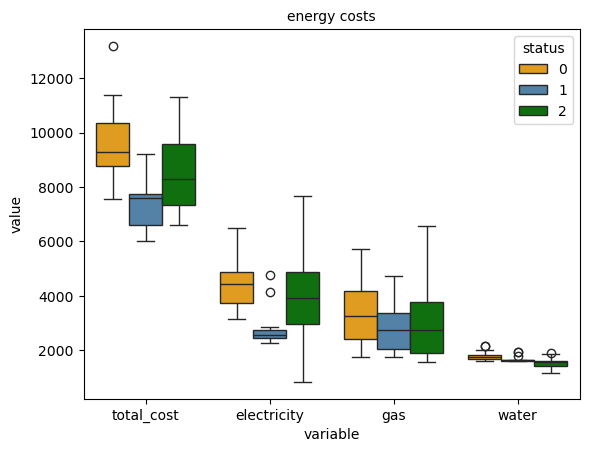

In [22]:
fig, ax = plt.subplots()
#ax2 = ax1.twinx()

dfx2 = dfx[['total_cost', 'electricity', 'gas', 'water', 'status']]

c1 = dfx2[dfx2['status'] == 1]['total_cost'].count()
print(c1)

dfx_mean = dfx2.groupby('status').mean()

print(dfx_mean)

print(f'Investment payback period (from 2020/3) = {(c1+(80000 - (dfx_mean['total_cost'].iloc[0] - dfx_mean['total_cost'].iloc[1])*c1)/(dfx_mean['total_cost'].iloc[0] - dfx_mean['total_cost'].iloc[2]))/12} nen ')

w = pd.melt(dfx2, id_vars = ['status'])
#display(w.head())

plt.title('energy costs', fontsize=10)
sns.boxplot(x = 'variable', y = 'value', data = w, hue = 'status', palette=['orange', 'steelblue', 'green'])
#plt.show()
#sns.stripplot(x = 'variable', y = 'value', data = w, hue = 'status', palette=['orange', 'steelblue', 'green'], ax=ax2)
#plt.show()
